# Mètriques d'errors de lectura

**Objectiu**: Calcular i comparar les mètriques d'error de lectura entre nens amb i sense dislèxia, a partir de les transcripcions automàtiques generades pel model ASR (Automatic Speech Recognition).

**Entrada**: fitxers CSV del directori `transcriptions/`, on cada fila representa una paraula amb el seu tipus d'operació d'edició (`correct`, `substitution`, `deletion`, `insertion`) i el temps de pronúncia.

**Sortida**: fitxer `datasets/error_metrics.csv` amb les mètriques agregades per fitxer d'àudio.

**Mètriques calculades**:
- **WER** (Word Error Rate): percentatge d'errors respecte les paraules objectiu
- **Accuracy**: percentatge de paraules llegides correctament
- **Taxes per tipus d'error**: substitucions, omissions (`deletion`) i addicions (`insertion`)
- **Paraules conflictives**: paraules amb temps per caràcter anormalment alt (z-score > 2), possibles indicadors de dificultat lectora

## 1. Imports i càlcul de mètriques per fitxer

Importem les llibreries i definim la funció `calculate_error_metrics`, que processa el CSV de transcripció d'un fitxer i retorna un diccionari amb totes les mètriques. Seguidament, apliquem la funció a tots els CSV del directori `transcriptions/` per construir el DataFrame `error_metrics_df`, etiquetat per grup (Dislèxia / No dislèxia) a partir del prefix `D_` al nom del fitxer.

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TRANSCRIPTIONS_DIR = Path("transcriptions")
OUTPUT_CSV = Path("./datasets/error_metrics.csv")


def calculate_error_metrics(df: pd.DataFrame) -> dict:
    """Compute error metrics from a transcription dataframe with a 'type' column."""
    if "type" not in df.columns:
        raise ValueError("Missing required column: type")

    op_types = df["type"].astype(str).str.strip().str.lower()

    n_correctes = int((op_types == "correct").sum())
    n_substitucions = int((op_types == "substitution").sum())
    n_omissions = int((op_types == "deletion").sum())
    n_addicions = int((op_types == "insertion").sum())

    n_paraules_objectiu = n_correctes + n_substitucions + n_omissions
    n_errors_totals = n_substitucions + n_omissions + n_addicions

    wer_percent = (n_errors_totals / n_paraules_objectiu * 100) if n_paraules_objectiu > 0 else 0.0
    accuracy_percent = (n_correctes / n_paraules_objectiu * 100) if n_paraules_objectiu > 0 else 0.0

    # Càlcul de paraules conflictives basat en el temps per caràcter i z-score
    time_per_char = df['total'] / df['hyp'].str.len()
    mu = time_per_char.mean(skipna=True)
    sigma = time_per_char.std(ddof=0, skipna=True)

    if pd.notna(sigma) and sigma > 0:
        z_scores = (time_per_char - mu) / sigma
        n_paraules_conflictives = int((z_scores > 2).sum())
        paraules_conflictives = df.loc[z_scores > 2, 'hyp'].tolist()
    else:
        n_paraules_conflictives = 0
        paraules_conflictives = []

    return {
        "n_correct": n_correctes,
        "n_sub": n_substitucions,
        "n_omis": n_omissions,
        "n_add": n_addicions,
        "n_err": n_errors_totals,
        "wer_lect": round(wer_percent, 2),
        "acc_lect": round(accuracy_percent, 2),
        "n_conf": n_paraules_conflictives
    }, paraules_conflictives


rows = []
transcription_files = []
for root, dirs, files in os.walk("transcriptions"):
    for file in files:
        if file.endswith(".csv"):
            file_path = Path(root) / file
            transcription_files.append(file_path)
print(f"Transcription files: {transcription_files}")
paraules_conflictives_totals = {}
for file_path in transcription_files:
    try:
        file_df = pd.read_csv(file_path)
        metrics, paraules_conflictives = calculate_error_metrics(file_df)
        metrics["filename"] = file_path.name
        metrics["Dyslexic"] = file_path.name.startswith("D_")
        rows.append(metrics)
        for paraula in paraules_conflictives:
            if paraula not in paraules_conflictives_totals:
                paraules_conflictives_totals[paraula] = 0
            paraules_conflictives_totals[paraula] += 1
    except Exception as exc:
        print(f"Skipping {file_path}: {exc}")

error_metrics_df = pd.DataFrame(rows)
error_metrics_df.to_csv(OUTPUT_CSV, index=False)

print(f"Processed files: {len(transcription_files)}")
print(f"Rows exported  : {len(error_metrics_df)}")
print(f"Saved CSV      : {OUTPUT_CSV.resolve()}")
display(error_metrics_df.head())

Transcription files: [WindowsPath('transcriptions/Escola 1/3A/Aiden8 - Los okapis (Castellano) - LlM_ (Castellano).csv'), WindowsPath('transcriptions/Escola 1/3A/Biel8 - Los okapis (Castellano) - LlM_ (Català).csv'), WindowsPath('transcriptions/Escola 1/3A/Cala9 - Los okapis (Castellano) - LlM_ (Català).csv'), WindowsPath('transcriptions/Escola 1/3A/Chloe8 - Los okapis (Castellano) - LlM_ (Castellano).csv'), WindowsPath('transcriptions/Escola 1/3A/D_Alex9 - Los okapis (Castellano) - LlM_ (Català).csv'), WindowsPath('transcriptions/Escola 1/3A/D_Arnau8 - Los okapis (Castellano) - LlM_ (Català).csv'), WindowsPath('transcriptions/Escola 1/3A/D_Berta8 - Los okapis (Castellano) - LlM_ (Castellano).csv'), WindowsPath('transcriptions/Escola 1/3A/D_Lena8 - Los okapis (Castellano) - LlM_ (Català).csv'), WindowsPath('transcriptions/Escola 1/3A/Judith9 - Los okapis (Castellano) - LlM_ (Català).csv'), WindowsPath('transcriptions/Escola 1/3A/Julia9 - Los okapis (Castellano) - LlM_ (Català).csv'), W

,n_correct,n_sub,n_omis,n_add,n_err,wer_lect,acc_lect,n_conf,filename,Dyslexic
0,63,1,11,0,12,16.00,84.00,2,Aiden8 - Los okapis (Castellano) - LlM_ (Caste...,False
1,75,0,0,0,0,0.00,100.00,5,Biel8 - Los okapis (Castellano) - LlM_ (Català...,False
2,72,3,0,0,3,4.00,96.00,3,Cala9 - Los okapis (Castellano) - LlM_ (Català...,False
3,72,3,0,0,3,4.00,96.00,3,Chloe8 - Los okapis (Castellano) - LlM_ (Caste...,False
4,71,4,0,1,5,6.67,94.67,6,D_Alex9 - Los okapis (Castellano) - LlM_ (Cata...,True


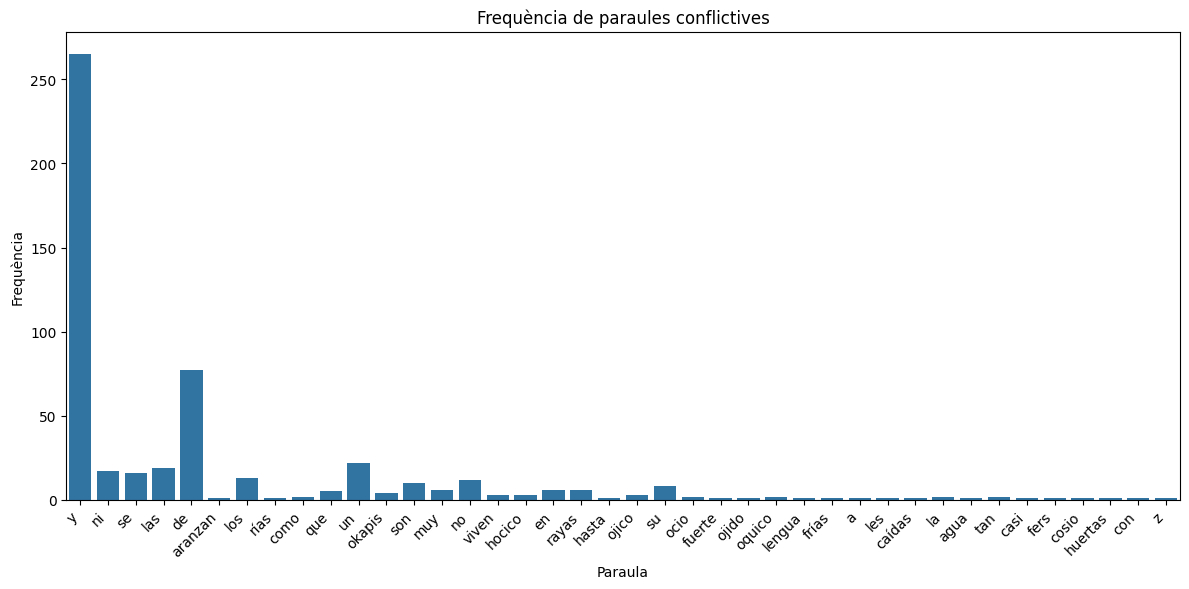

In [2]:
# Visualitzar heatmap de les paraules conflictives més comunes. Mostrar tot el vocabulari i les seves freqüències. --- IGNORE ---
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(x=list(paraules_conflictives_totals.keys()), y=list(paraules_conflictives_totals.values()))
plt.xticks(rotation=45, ha='right')
plt.title("Frequència de paraules conflictives")
plt.xlabel("Paraula")
plt.ylabel("Frequència")
plt.tight_layout()
plt.show()

## 2. Visualització comparativa

Representem la distribució de cada mètrica mitjançant **violin plots** amb punts individuals superposats, per als dos grups (dislèxia i control). Aquesta visualització permet comparar simultàniament la forma de la distribució, la mediana i els valors atípics de cada grup.

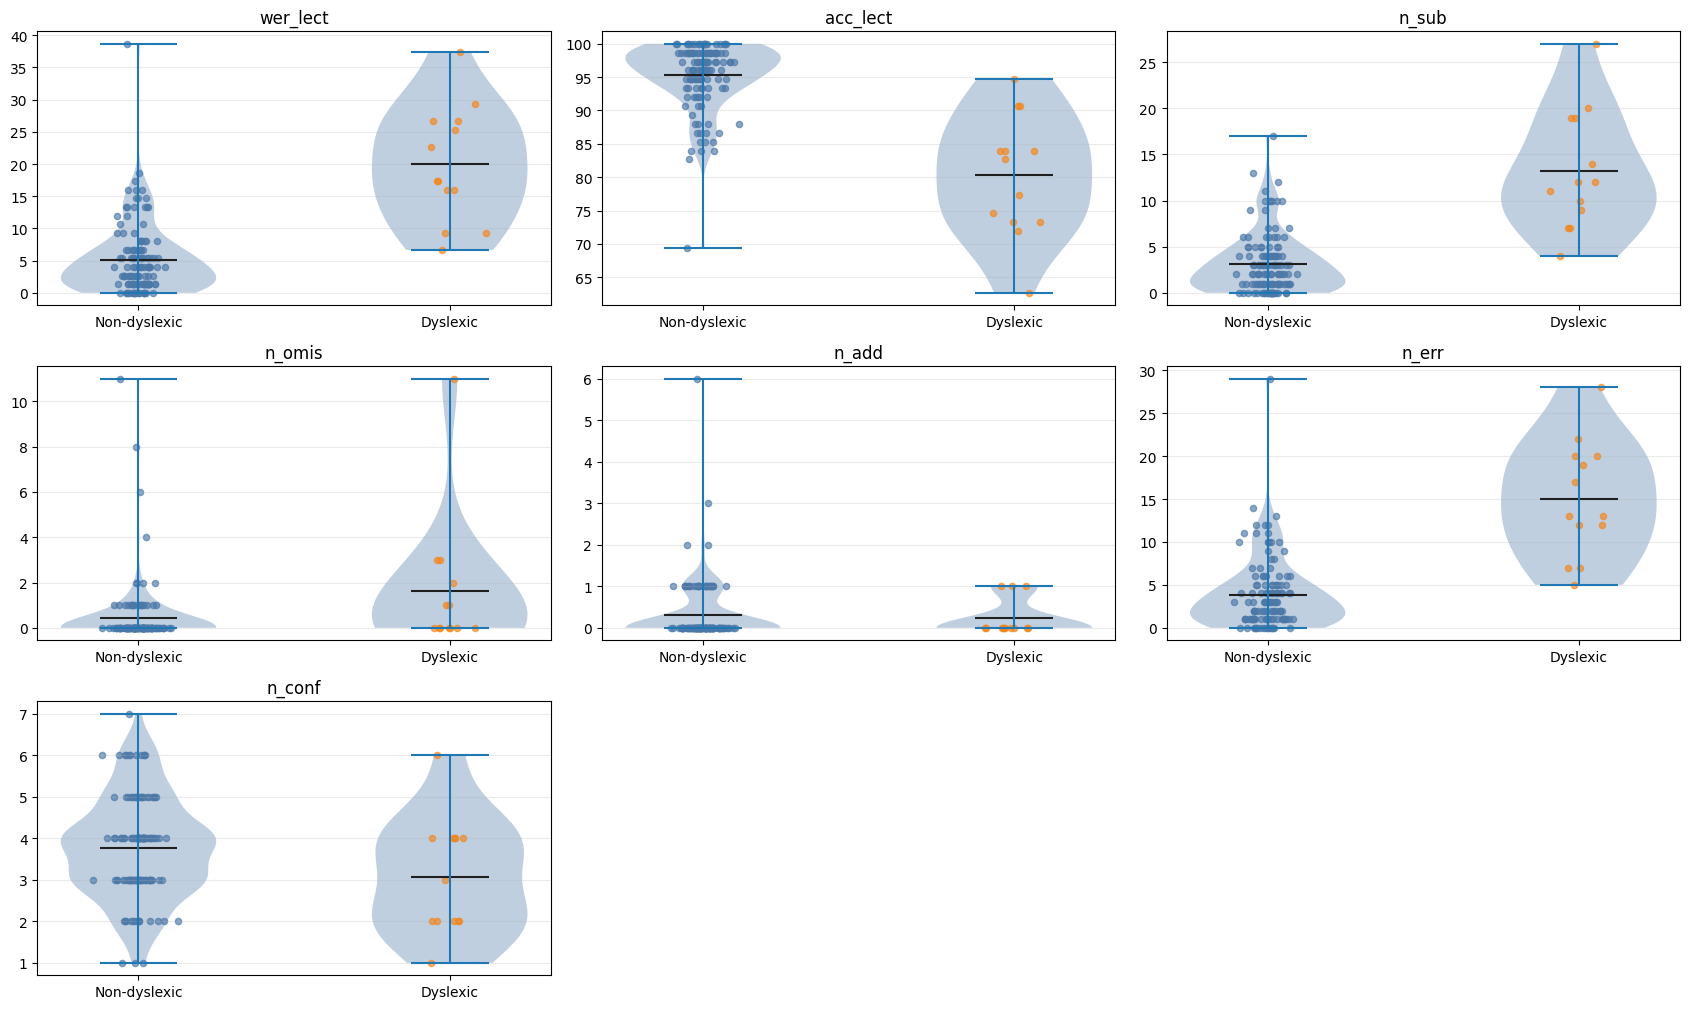

In [ ]:
if error_metrics_df.empty:
    print("No data available for additional visualizations.")
else:
    metric_cols = [
        "wer_lect",
        "acc_lect",
        "n_sub",
        "n_omis",
        "n_add",
        "n_err",
        "n_conf",
    ]

    df_vis = error_metrics_df.copy()
    df_vis["Group"] = np.where(df_vis["Dyslexic"], "Dyslexic", "Non-dyslexic")

    # Create only the necessary subplot grid and remove extras
    n_metrics = len(metric_cols)
    ncols = 3
    nrows = int(np.ceil(n_metrics / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(17, 3.4 * nrows))
    axes = np.atleast_1d(axes).flatten()

    rng = np.random.default_rng(42)

    for ax, col in zip(axes, metric_cols):
        non_vals = df_vis.loc[df_vis["Group"] == "Non-dyslexic", col].dropna().to_numpy()
        dys_vals = df_vis.loc[df_vis["Group"] == "Dyslexic", col].dropna().to_numpy()

        if len(non_vals) > 0 and len(dys_vals) > 0:
            parts = ax.violinplot([non_vals, dys_vals], positions=[1, 2], showmeans=True, showextrema=True)
            for pc in parts["bodies"]:
                pc.set_alpha(0.35)
                pc.set_facecolor("#4C78A8")
            parts["cmeans"].set_color("#1F1F1F")

            x_non = rng.normal(1, 0.04, size=len(non_vals))
            x_dys = rng.normal(2, 0.04, size=len(dys_vals))
            ax.scatter(x_non, non_vals, alpha=0.65, s=20, color="#4C78A8")
            ax.scatter(x_dys, dys_vals, alpha=0.65, s=20, color="#F58518")

            ax.set_xticks([1, 2])
            ax.set_xticklabels(["Non-dyslexic", "Dyslexic"])
            ax.set_title(f"{col}")
            ax.grid(axis="y", alpha=0.25)
        else:
            ax.text(0.5, 0.5, "Not enough data", ha="center", va="center")
            ax.set_title(f"{col}")
            ax.set_axis_off()

    # Remove unused axes so no empty plots are shown
    for ax in axes[n_metrics:]:
        fig.delaxes(ax)

    plt.tight_layout()
    #plt.savefig("./imatges/error_metrics_violin_plots.pdf")
    plt.show()


## 3. Contrast estadístic (Welch t-test)

Per a cada mètrica, apliquem un **t-test de Welch** (que no assumeix homogeneïtat de variàncies) per determinar si les diferències entre grups són estadísticament significatives (p < 0.05). Les variables significatives s'identifiquen com a candidates a incloure al model de classificació.

In [5]:
from scipy.stats import ttest_ind

def fdr_bh(p_values):
    '''Correcció de Benjamini-Hochberg per comparacions múltiples.'''
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    order = np.argsort(p)
    p_sorted = p[order]
    prev, q_sorted = 1.0, np.empty(m)
    for i in range(m - 1, -1, -1):
        prev = min(prev, (m / (i + 1)) * p_sorted[i])
        q_sorted[i] = prev
    q = np.empty(m)
    q[order] = np.minimum(q_sorted, 1.0)
    return q


def hedges_g(x, y):
    '''Mida d\'efecte de Hedges g.'''
    x, y = np.asarray(x)[np.isfinite(np.asarray(x))], np.asarray(y)[np.isfinite(np.asarray(y))]
    if len(x) < 2 or len(y) < 2:
        return np.nan
    n1, n2 = len(x), len(y)
    s_pool = np.sqrt(((n1 - 1) * np.var(x, ddof=1) + (n2 - 1) * np.var(y, ddof=1)) / (n1 + n2 - 2))
    if s_pool == 0:
        return 0.0
    d = (np.mean(x) - np.mean(y)) / s_pool
    return d * (1 - 3 / (4 * (n1 + n2) - 9))


rows = []
for feat in metric_cols:
    ctrl_vals = df_vis.loc[df_vis['Group'] == 'Non-dyslexic', feat].dropna()
    dys_vals = df_vis.loc[df_vis['Group'] == 'Dyslexic', feat].dropna()
    if len(ctrl_vals) >= 2 and len(dys_vals) >= 2:
        t_stat, p_val = ttest_ind(dys_vals, ctrl_vals, equal_var=False)
    else:
        t_stat, p_val = np.nan, np.nan
    rows.append({
        'variable': feat,
        'n_control': len(ctrl_vals),
        'n_dislexia': len(dys_vals),
        'mitjana_control': ctrl_vals.mean() if len(ctrl_vals) else np.nan,
        'mitjana_dislexia': dys_vals.mean() if len(dys_vals) else np.nan,
        'diferencia': (dys_vals.mean() - ctrl_vals.mean()) if (len(ctrl_vals) and len(dys_vals)) else np.nan,
        't_stat': t_stat,
        'p_value': p_val,
        'hedges_g': hedges_g(dys_vals, ctrl_vals),
    })

df_stats = pd.DataFrame(rows)
valid = df_stats['p_value'].notna()
q_vals = np.full(len(df_stats), np.nan)
if valid.sum() > 0:
    q_vals[valid] = fdr_bh(df_stats.loc[valid, 'p_value'].values)
df_stats['q_value_fdr'] = q_vals
df_stats['significatiu_fdr'] = df_stats['q_value_fdr'] < 0.05
df_stats = df_stats.sort_values('p_value')

print('=== Resultats estadístics (Welch t-test + FDR-BH) ===')
display(df_stats.set_index('variable').round(4))

sig = df_stats[df_stats['significatiu_fdr']]
print(f'\nVariables significatives (q<0.05): {len(sig)}')
if len(sig) > 0:
    for _, r in sig.iterrows():
        print(f'  {r["variable"]}: g={r["hedges_g"]:.3f}, q={r["q_value_fdr"]:.4f}')

=== Resultats estadístics (Welch t-test + FDR-BH) ===


,n_control,n_dislexia,mitjana_control,mitjana_dislexia,diferencia,t_stat,p_value,hedges_g,q_value_fdr,significatiu_fdr
variable,,,,,,,,,,
n_err,128,13,3.8672,15.0000,11.1328,5.8651,0.0001,2.5442,0.0001,True
wer_lect,128,13,5.1558,19.9992,14.8434,5.8650,0.0001,2.5440,0.0001,True
acc_lect,128,13,95.2504,80.3085,-14.9419,-5.8586,0.0001,-2.7641,0.0001,True
n_sub,128,13,3.1406,13.1538,10.0132,5.5154,0.0001,2.7651,0.0002,True
n_conf,128,13,3.7656,3.0769,-0.6887,-1.7309,0.1056,-0.5601,0.1478,False
n_omis,128,13,0.4219,1.6154,1.1935,1.3995,0.1859,0.7394,0.2169,False
n_add,128,13,0.3047,0.2308,-0.0739,-0.5374,0.5971,-0.1040,0.5971,False



Variables significatives (q<0.05): 4
  n_err: g=2.544, q=0.0001
  wer_lect: g=2.544, q=0.0001
  acc_lect: g=-2.764, q=0.0001
  n_sub: g=2.765, q=0.0002
